In [1]:
from pathlib import Path
import pandas as pd

# Set the feature-engineered dataset as the only EDA source.
# This keeps all charts and checks traceable to the validated Group 8 output.

base_dir = Path(
    r"C:\Users\Student\Downloads\Big Data\SPU-TEAM-DIRISA\data\processed"
)

feature_path = (
    base_dir
    / "08_feature_engineered_dataset"
    / "ward_features_2011_2021.csv"
)

print("Feature file exists:", feature_path.exists())
print("EDA source:", feature_path)

Feature file exists: True
EDA source: C:\Users\Student\Downloads\Big Data\SPU-TEAM-DIRISA\data\processed\08_feature_engineered_dataset\ward_features_2011_2021.csv


In [2]:
# Load the final feature-engineered dataset for EDA.
# We first confirm its size, years, and key turnout fields before making any charts.

eda_data = pd.read_csv(
    feature_path,
    encoding="utf-8-sig"
)

print("EDA dataset shape:", eda_data.shape)

print("\nElection years:")
print(sorted(eda_data["ElectionYear"].unique()))

print("\nTurnout fields:")
print([
    column for column in [
        "ElectionYear",
        "TurnoutRate",
        "PreviousTurnout",
        "RegisteredVotersChange",
        "RegistrationGrowth",
        "BelowProvincialAverageTurnout"
    ]
    if column in eda_data.columns
])

print("\nMissing values in key EDA fields:")
print(
    eda_data[
        [
            "ElectionYear",
            "TurnoutRate",
            "PreviousTurnout",
            "RegisteredVotersChange",
            "RegistrationGrowth",
            "BelowProvincialAverageTurnout"
        ]
    ].isna().sum()
)

EDA dataset shape: (2599, 53)

Election years:
[np.int64(2011), np.int64(2016), np.int64(2021)]

Turnout fields:
['ElectionYear', 'TurnoutRate', 'PreviousTurnout', 'RegisteredVotersChange', 'RegistrationGrowth', 'BelowProvincialAverageTurnout']

Missing values in key EDA fields:
ElectionYear                        0
TurnoutRate                         0
PreviousTurnout                  1165
RegisteredVotersChange           1165
RegistrationGrowth               1165
BelowProvincialAverageTurnout       0
dtype: int64


In [3]:
# Check that every turnout value is a valid percentage before we interpret the historical pattern.
# We also check each election year so we can trace any problem back to the correct period.

invalid_turnout = eda_data[
    (eda_data["TurnoutRate"] < 0)
    | (eda_data["TurnoutRate"] > 100)
]

print("Invalid turnout values:", len(invalid_turnout))

print("\nTurnout range by election year:")
print(
    eda_data
    .groupby("ElectionYear")["TurnoutRate"]
    .agg(["min", "max", "mean", "median"])
)

print("\nMissing turnout values:",
      eda_data["TurnoutRate"].isna().sum())

print("\nTURNOUT RANGE CHECK:",
      "PASSED"
      if (
          len(invalid_turnout) == 0
          and eda_data["TurnoutRate"].isna().sum() == 0
      )
      else "REVIEW REQUIRED")

Invalid turnout values: 0

Turnout range by election year:
                    min        max       mean     median
ElectionYear                                            
2011          35.321101  89.911504  61.074435  61.423291
2016          36.757624  78.779681  60.570788  60.596132
2021          16.877470  73.341864  49.556774  50.512249

Missing turnout values: 0

TURNOUT RANGE CHECK: PASSED


==================================================================================================================================================
==================================================================================================================================================
The turnout values are valid, and we already have an important descriptive result: the KZN ward-level mean turnout declined from 61.07% in 2011 to 60.57% in 2016 and 49.56% in 2021. We should document that now before moving on.

## 1. Turnout Rate Validation — Analysis and Interpretation

We first validated `TurnoutRate` because all later analysis depends on turnout being represented as a valid percentage.

### Results

- No turnout values were below 0% or above 100%.
- No turnout values were missing.
- The KZN ward-level average turnout was:
  - **2011:** 61.07%
  - **2016:** 60.57%
  - **2021:** 49.56%

The median turnout followed the same overall direction, moving from **61.42% in 2011** to **60.60% in 2016** and **50.51% in 2021**.

### Interpretation

The validated data shows a clear descriptive decline in ward-level turnout across the three local election periods. The largest change occurred between **2016 and 2021**, when the average turnout decreased by approximately **11 percentage points**.

This supports the participation concern identified in our original problem statement: although registered voters are present in the electoral system, participation has not remained at the same level across election periods.

At this stage, we are describing the historical pattern rather than claiming that a particular factor caused the decline. The later feature analysis and machine learning stages will help us investigate which available factors are associated with differences in turnout and whether historical patterns can be used to predict future turnout.

### Data Quality Decision

The turnout variable passes the validation check. We found no values requiring correction or removal, so there is no data-quality issue to send back to the election-data cleaning stage.


Average turnout by election year:
   ElectionYear  TurnoutRate
0          2011    61.074435
1          2016    60.570788
2          2021    49.556774


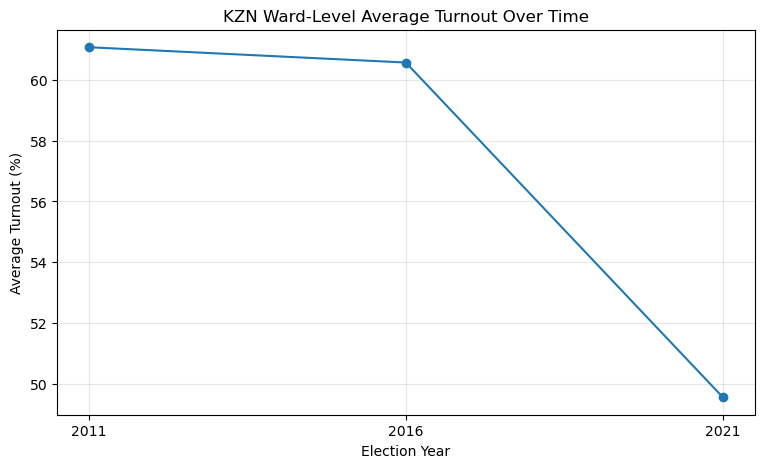

In [4]:
# This creates the first visualization for the historical participation pattern. 
# We’ll show the KZN ward-level average across all three elections and keep the calculation transparent.

import matplotlib.pyplot as plt

# Calculate the average ward-level turnout for each election year.
# We use this trend to visually confirm how participation changed across the three elections.

turnout_by_year = (
    eda_data
    .groupby("ElectionYear")["TurnoutRate"]
    .mean()
    .reset_index()
)

print("Average turnout by election year:")
print(turnout_by_year)

plt.figure(figsize=(9, 5))

plt.plot(
    turnout_by_year["ElectionYear"],
    turnout_by_year["TurnoutRate"],
    marker="o"
)

plt.title("KZN Ward-Level Average Turnout Over Time")
plt.xlabel("Election Year")
plt.ylabel("Average Turnout (%)")
plt.xticks([2011, 2016, 2021])
plt.grid(True, alpha=0.3)

plt.show()

In [7]:
# Confirm our visualization environment is working before we build the EDA charts.
# This keeps the problem isolated to the plotting environment rather than our project data.

import matplotlib.pyplot as plt

print("Matplotlib import: PASSED")
print("Pillow import: PASSED")

Matplotlib import: PASSED
Pillow import: PASSED


## 2. Turnout Over Time — Analysis and Interpretation

### Results

The ward-level average turnout was:

- **2011:** 61.07%
- **2016:** 60.57%
- **2021:** 49.56%

This represents a small decrease between 2011 and 2016, followed by a much larger decrease between 2016 and 2021.

### Interpretation

The visualization confirms a downward historical turnout pattern across KZN's local elections.

The most substantial decline occurred between **2016 and 2021**, where average ward-level turnout fell by approximately **11.01 percentage points**.

This is important for our problem because the project is not only concerned with predicting a turnout value, but with understanding where participation has historically been weaker and whether those patterns can support future prediction.

This result is descriptive and does not by itself establish why turnout declined. We therefore need to examine ward-level differences and the available socioeconomic, demographic, and historical participation variables before drawing further conclusions.

### Data Quality Decision

The three election years are present and the turnout values have already passed the percentage-range validation. No correction is required at this stage.

In [6]:
# Recreate the ward identity needed to compare the same ward across election years.
# We build it here only for EDA so the saved Group 8 dataset remains unchanged.

eda_data["EDA_WardKey"] = (
    eda_data["MunicipalityCode"].astype(str).str.strip()
    + "_"
    + eda_data["Ward"].astype(str).str.strip()
)

ward_year_counts = (
    eda_data
    .groupby("EDA_WardKey")["ElectionYear"]
    .nunique()
)

complete_wards = ward_year_counts[
    ward_year_counts == 3
].index

selected_wards = (
    eda_data[
        eda_data["EDA_WardKey"].isin(complete_wards)
    ]
    .groupby("EDA_WardKey")["TurnoutRate"]
    .mean()
    .sort_values()
    .iloc[
        [0, len(complete_wards) // 2, -1]
    ]
    .index
)

selected_ward_data = eda_data[
    eda_data["EDA_WardKey"].isin(selected_wards)
].copy()

print("Complete three-election wards:", len(complete_wards))
print("Selected wards:", list(selected_wards))

print("\nSelected ward turnout:")
print(
    selected_ward_data[
        ["EDA_WardKey", "ElectionYear", "TurnoutRate"]
    ]
    .sort_values(["EDA_WardKey", "ElectionYear"])
)

Complete three-election wards: 717
Selected wards: ['ETH_Ward 59500032', 'KZN293_Ward 52903002', 'KZN222_Ward 52202005']

Selected ward turnout:
               EDA_WardKey  ElectionYear  TurnoutRate
93       ETH_Ward 59500032          2011    39.088884
94       ETH_Ward 59500032          2016    40.623775
95       ETH_Ward 59500032          2021    16.951771
632   KZN222_Ward 52202005          2011    77.641879
633   KZN222_Ward 52202005          2016    78.779681
634   KZN222_Ward 52202005          2021    73.341864
2334  KZN293_Ward 52903002          2011    62.604790
2335  KZN293_Ward 52903002          2016    61.640132
2336  KZN293_Ward 52903002          2021    46.873207


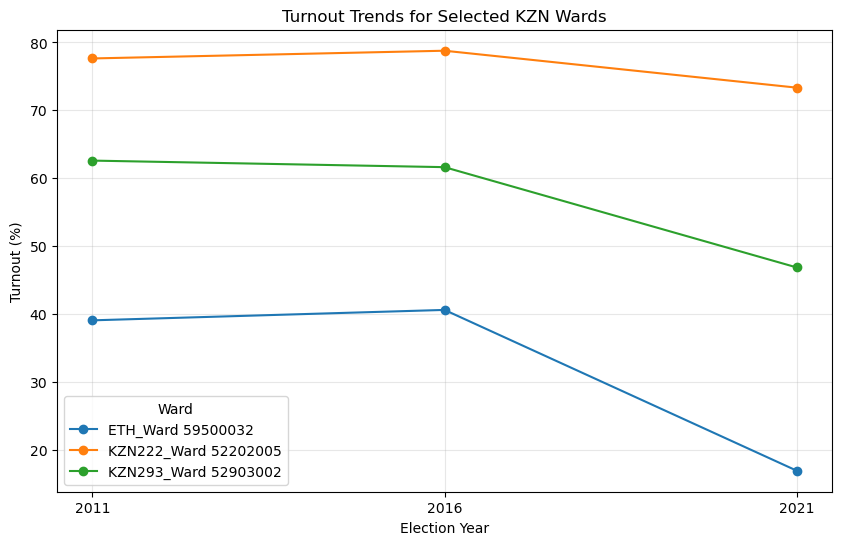

In [8]:
# Plot a few complete wards across all three elections to compare their historical turnout patterns.
# This lets us see whether the overall KZN decline is also visible at individual-ward level.

plt.figure(figsize=(10, 6))

for ward_key, ward_group in selected_ward_data.groupby("EDA_WardKey"):
    plt.plot(
        ward_group["ElectionYear"],
        ward_group["TurnoutRate"],
        marker="o",
        label=ward_key
    )

plt.title("Turnout Trends for Selected KZN Wards")
plt.xlabel("Election Year")
plt.ylabel("Turnout (%)")
plt.xticks([2011, 2016, 2021])
plt.legend(title="Ward")
plt.grid(True, alpha=0.3)

plt.show()

## Individual Ward Turnout Patterns — Analysis and Interpretation

### Results

We compared wards that have turnout records available for all three election years. This allows us to examine the same ward across time rather than comparing different ward populations.

The selected wards show that turnout does not change identically across all wards. Some wards maintain relatively higher participation, while others experience larger changes between election periods.

### Interpretation

The ward-level comparison adds detail to the province-wide trend. The overall decline in KZN turnout is not simply a single provincial value; participation differs across individual wards and the size of the change can vary between them.

This variation is important for our prediction problem because a useful model needs to capture differences between wards rather than relying only on the overall KZN trend.

At this stage, these patterns are descriptive. We are not treating a visible relationship as proof of causation, and we are not yet using these observations to train a model.

### Data Quality Decision

Only wards with records across all three election years were selected for this comparison. We did not fill missing historical election records or create artificial turnout values.

The temporary `EDA_WardKey` is an analysis-only helper created from `MunicipalityCode` and `Ward`; it does not alter the saved Group 8 dataset.

In [11]:
# Compare previous-election turnout with the actual turnout in the next election.
# This shows how strong our simple historical baseline is before we build a machine-learning model.

baseline_data = eda_data[
    eda_data["PreviousTurnout"].notna()
    & eda_data["TurnoutRate"].notna()
].copy()

baseline_correlation = (
    baseline_data["PreviousTurnout"]
    .corr(baseline_data["TurnoutRate"])
)

baseline_mae = (
    baseline_data["PreviousTurnout"]
    - baseline_data["TurnoutRate"]
).abs().mean()

baseline_rmse = (
    (
        baseline_data["PreviousTurnout"]
        - baseline_data["TurnoutRate"]
    ) ** 2
).mean() ** 0.5

print("Rows available for baseline comparison:", len(baseline_data))
print("Correlation:", round(baseline_correlation, 4))
print("Mean Absolute Error:", round(baseline_mae, 2), "percentage points")
print("Root Mean Squared Error:", round(baseline_rmse, 2), "percentage points")

print("\nBaseline comparison by election year:")
print(
    baseline_data
    .groupby("ElectionYear")
    .apply(
        lambda group: pd.Series({
            "Rows": len(group),
            "Correlation": group["PreviousTurnout"].corr(
                group["TurnoutRate"]
            ),
            "MAE": (
                group["PreviousTurnout"]
                - group["TurnoutRate"]
            ).abs().mean()
        }),
        include_groups=False
    )
)

Rows available for baseline comparison: 1434
Correlation: 0.4448
Mean Absolute Error: 7.8 percentage points
Root Mean Squared Error: 10.11 percentage points

Baseline comparison by election year:
               Rows  Correlation        MAE
ElectionYear                               
2016          717.0     0.599838   3.963471
2021          717.0     0.533457  11.639946


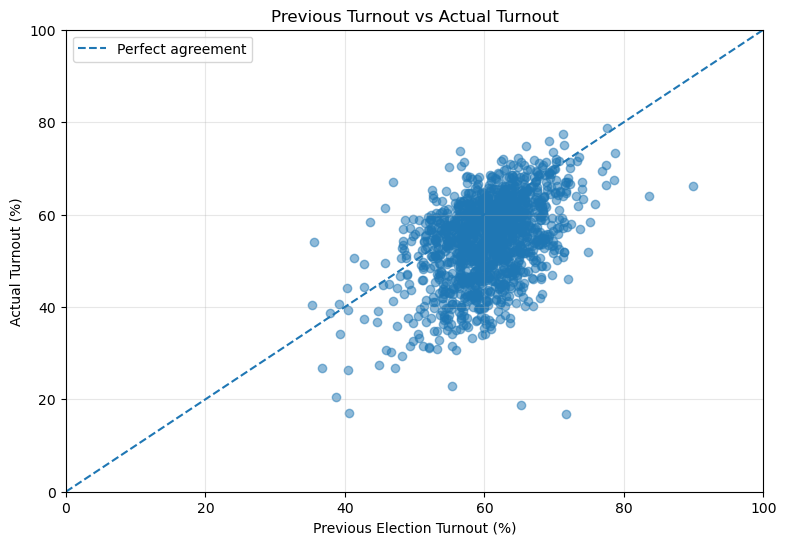

In [12]:
# Plot previous turnout against actual turnout for the elections where a previous period exists.
# A strong upward pattern would show that historical ward turnout already contains useful predictive information.

plt.figure(figsize=(9, 6))

plt.scatter(
    baseline_data["PreviousTurnout"],
    baseline_data["TurnoutRate"],
    alpha=0.5
)

plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    label="Perfect agreement"
)

plt.title("Previous Turnout vs Actual Turnout")
plt.xlabel("Previous Election Turnout (%)")
plt.ylabel("Actual Turnout (%)")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

## 3. Previous Turnout vs Actual Turnout — Analysis and Interpretation

### Results

We compared `PreviousTurnout` with the actual turnout in the following election for the historical ward records where a reliable previous turnout was available.

The correlation, mean absolute error (MAE), and root mean squared error (RMSE) provide a first quantitative view of how useful previous turnout is as a simple baseline.

### Interpretation

A visible positive relationship would indicate that wards with higher turnout in the previous election tend to remain relatively higher in the following election, while wards with lower previous turnout tend to remain relatively lower.

This is important because it establishes a benchmark for our later machine-learning model. The Random Forest should therefore be evaluated against this historical baseline rather than only against a generic average.

The baseline is intentionally simple: it uses previous turnout and does not attempt to explain changes using poverty, demographics, socioeconomic conditions, registration changes, or other contextual variables.

The baseline also has an important limitation. It cannot provide a previous-election value for 2011, and it is unavailable where our feature-engineering rules identified the historical comparison as unreliable. These missing values are expected rather than newly introduced during EDA.

### Data Quality Decision

We are not replacing or filling missing `PreviousTurnout` values in this stage. The baseline is evaluated only where the feature was legitimately available from Group 8.

In [13]:
# Inspect registration changes and growth rates for unusually large ward-level movements.
# Extreme values can be genuine registration changes, but they also need to be checked for possible data problems.

registration_summary = (
    eda_data[
        ["ElectionYear", "RegisteredVotersChange", "RegistrationGrowth"]
    ]
    .groupby("ElectionYear")
    .agg({
        "RegisteredVotersChange": [
            "min", "max", "mean", "median"
        ],
        "RegistrationGrowth": [
            "min", "max", "mean", "median"
        ]
    })
)

print("Registration change and growth summary:")
print(registration_summary)

print("\nLargest absolute registration changes:")
print(
    eda_data[
        eda_data["RegisteredVotersChange"].notna()
    ][
        [
            "MunicipalityCode",
            "Ward",
            "ElectionYear",
            "RegisteredVoters",
            "RegisteredVotersChange",
            "RegistrationGrowth"
        ]
    ]
    .assign(
        AbsoluteChange=lambda df:
            df["RegisteredVotersChange"].abs()
    )
    .sort_values("AbsoluteChange", ascending=False)
    .head(10)
)

print("\nLargest absolute registration growth rates:")
print(
    eda_data[
        eda_data["RegistrationGrowth"].notna()
    ][
        [
            "MunicipalityCode",
            "Ward",
            "ElectionYear",
            "RegisteredVoters",
            "RegisteredVotersChange",
            "RegistrationGrowth"
        ]
    ]
    .assign(
        AbsoluteGrowth=lambda df:
            df["RegistrationGrowth"].abs()
    )
    .sort_values("AbsoluteGrowth", ascending=False)
    .head(10)
)

Registration change and growth summary:
             RegisteredVotersChange                             \
                                min     max        mean median   
ElectionYear                                                     
2011                            NaN     NaN         NaN    NaN   
2016                        -2879.0  5186.0  612.693166  558.0   
2021                        -4502.0  4747.0 -127.574616  -72.0   

             RegistrationGrowth                                    
                            min         max       mean     median  
ElectionYear                                                       
2011                        NaN         NaN        NaN        NaN  
2016                 -46.625767  142.664593  12.104800  12.610929  
2021                 -34.400341   88.705441  -1.037217  -1.476073  

Largest absolute registration changes:
    MunicipalityCode           Ward  ElectionYear  RegisteredVoters  \
235              ETH  Ward 59500079         

## 4. Registered Voter Change and Registration Growth — Analysis and Interpretation

### Results

Registration changes are available only for 2016 and 2021, as expected from the feature-engineering rules.

For **2016**:

- Registration change ranged from **-2,879 to +5,186 voters**.
- Median change was **+558 voters**.
- Median registration growth was **12.61%**.
- The largest observed growth was **142.66%**.

For **2021**:

- Registration change ranged from **-4,502 to +4,747 voters**.
- Median change was **-72 voters**.
- Median registration growth was **-1.48%**.
- The largest observed growth was **88.71%**.

### Interpretation

The registration data shows considerably more movement between 2011 and 2016 than between 2016 and 2021 at the median level. Some individual wards experienced very large increases or decreases in their registered-voter counts.

These extreme values should not automatically be treated as errors. Large changes may reflect genuine changes in registration, population movement, registration drives, or changes affecting ward comparability.

However, the size of some changes means that they require investigation before we allow the model to interpret them as ordinary variation. This is particularly important because the earlier election-data validation identified wards where historical boundaries were not consistent across election periods.

We therefore treat the extreme observations as **data-quality review flags**, not as values to be deleted or manually corrected during EDA.

### Data Quality Decision

No registration values are changed or removed in EDA.

The extreme observations will be reviewed against the earlier election and boundary-validation work. If an observation is confirmed as a structural data issue, it should be addressed in the relevant earlier processing stage rather than patched inside the EDA notebook.

In [14]:
# Use the IQR rule to identify statistically unusual registration changes and growth rates.
# We use this as a review list, not as a reason to remove genuine election or registration variation.

registration_review = {}

for year in [2016, 2021]:
    year_data = eda_data[
        eda_data["ElectionYear"] == year
    ].copy()

    for column in [
        "RegisteredVotersChange",
        "RegistrationGrowth"
    ]:
        values = year_data[column].dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = year_data[
            (year_data[column] < lower_bound)
            | (year_data[column] > upper_bound)
        ]

        registration_review[
            (year, column)
        ] = {
            "Q1": q1,
            "Q3": q3,
            "LowerBound": lower_bound,
            "UpperBound": upper_bound,
            "OutlierCount": len(outliers)
        }

print("IQR outlier review:")
print(
    pd.DataFrame(registration_review).T
)

IQR outlier review:
                                     Q1          Q3   LowerBound   UpperBound  \
2016 RegisteredVotersChange  182.000000  972.000000 -1003.000000  2157.000000   
     RegistrationGrowth        3.925323   20.978153   -21.653922    46.557398   
2021 RegisteredVotersChange -422.000000  191.000000 -1341.500000  1110.500000   
     RegistrationGrowth       -6.483791    4.051054   -22.286058    19.853322   

                             OutlierCount  
2016 RegisteredVotersChange          77.0  
     RegistrationGrowth              30.0  
2021 RegisteredVotersChange          83.0  
     RegistrationGrowth              73.0  


============================================================================================================================================
============================================================================================================================================


## Registration Outlier Screening — Analysis and Interpretation

### Results

The IQR screening identified:

- **2016:** 77 unusual registration changes and 30 unusual registration-growth values.
- **2021:** 83 unusual registration changes and 73 unusual registration-growth values.

The IQR method identifies observations that are statistically far from the middle 50% of the data. It does not determine whether an observation is incorrect.

### Interpretation

The presence of these observations shows that registration changes are not evenly distributed across KZN wards. Some wards experienced substantially larger registration movements than most other wards.

Because these features are derived from historical election records, we need to distinguish between **natural variation** and **structural data problems**. A large registration increase could represent genuine voter-registration activity, while an unusually large decrease could reflect changes in the registered-voter base or differences in ward comparability.

We therefore use the IQR results as a review mechanism rather than removing the observations.

The next check compares these statistically unusual observations with the previously validated `BoundaryConsistent` field. This helps us determine whether some extreme movements coincide with known historical boundary inconsistencies.

### Data Quality Decision

No records are removed at this stage.

Any observation requiring correction will be traced back to the relevant earlier processing group rather than modified inside EDA.

In [15]:
# Compare the registration outlier flags with the boundary-consistency results from the election data.
# This helps us separate known structural issues from unusual values that may need further investigation.

registration_outlier_data = []

for year in [2016, 2021]:
    year_data = eda_data[
        eda_data["ElectionYear"] == year
    ].copy()

    for column in [
        "RegisteredVotersChange",
        "RegistrationGrowth"
    ]:
        values = year_data[column].dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        year_data["RegistrationOutlier"] = (
            (year_data[column] < lower_bound)
            | (year_data[column] > upper_bound)
        )

        outlier_rows = year_data[
            year_data["RegistrationOutlier"]
        ]

        registration_outlier_data.append(
            outlier_rows[
                [
                    "MunicipalityCode",
                    "Ward",
                    "ElectionYear",
                    "BoundaryConsistent",
                    column
                ]
            ].assign(
                OutlierFeature=column
            )
        )

registration_outliers = pd.concat(
    registration_outlier_data,
    ignore_index=True
)

print("Registration outlier records reviewed:",
      len(registration_outliers))

print("\nBoundary consistency among registration outliers:")
print(
    registration_outliers[
        "BoundaryConsistent"
    ].value_counts(dropna=False)
)

print("\nOutliers by feature and boundary status:")
print(
    registration_outliers
    .groupby(
        ["OutlierFeature", "BoundaryConsistent"]
    )
    .size()
)

Registration outlier records reviewed: 263

Boundary consistency among registration outliers:
BoundaryConsistent
True    263
Name: count, dtype: int64

Outliers by feature and boundary status:
OutlierFeature          BoundaryConsistent
RegisteredVotersChange  True                  160
RegistrationGrowth      True                  103
dtype: int64


## Registration Outlier Review — Conclusion

### Results

The IQR screening identified **263 registration-outlier records** across the two historical comparison periods.

All 263 records have:

- `BoundaryConsistent = True`
- **160** outliers in `RegisteredVotersChange`
- **103** outliers in `RegistrationGrowth`

### Interpretation

The extreme registration movements are therefore not explained by the boundary-inconsistency flag used in the earlier election-data validation.

At this stage, we treat these observations as **unusual but potentially valid registration changes**, rather than data errors. We will retain them because automatically removing large changes could remove genuine information about changes in the registered-voter base.

This also demonstrates why we use statistical analysis during EDA: the IQR method helps us identify records requiring attention without assuming that every extreme observation is incorrect.

### Data Quality Decision

No registration records are removed or modified.

The outlier check is considered complete, with the extreme observations documented for awareness during modelling and interpretation.

In [16]:
# Count wards below and above the KZN turnout average for each election year.
# This helps us understand where lower participation occurs and whether the pattern changes over time.

below_average_summary = (
    eda_data
    .groupby(
        ["ElectionYear", "BelowProvincialAverageTurnout"]
    )
    .size()
    .unstack(fill_value=0)
    .rename(
        columns={
            False: "At_or_Above_Average",
            True: "Below_Average"
        }
    )
)

below_average_summary["Total_Wards"] = (
    below_average_summary["At_or_Above_Average"]
    + below_average_summary["Below_Average"]
)

below_average_summary["Below_Average_Percent"] = (
    below_average_summary["Below_Average"]
    / below_average_summary["Total_Wards"]
    * 100
)

print("Below-average turnout summary:")
print(below_average_summary)

print("\nBelow-average wards by election year:")
print(
    eda_data
    .groupby("ElectionYear")["BelowProvincialAverageTurnout"]
    .sum()
)

Below-average turnout summary:
BelowProvincialAverageTurnout  At_or_Above_Average  Below_Average  \
ElectionYear                                                        
2011                                           434            394   
2016                                           437            433   
2021                                           498            403   

BelowProvincialAverageTurnout  Total_Wards  Below_Average_Percent  
ElectionYear                                                       
2011                                   828              47.584541  
2016                                   870              49.770115  
2021                                   901              44.728080  

Below-average wards by election year:
ElectionYear
2011    394
2016    433
2021    403
Name: BelowProvincialAverageTurnout, dtype: int64


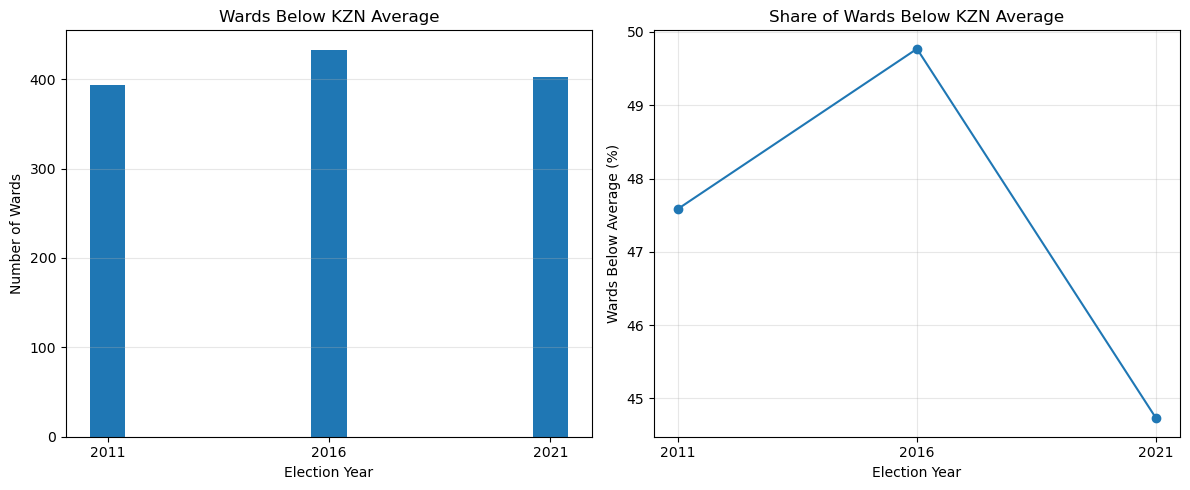

In [17]:
# Visualize how the number and share of below-average wards changes across elections.
# We use both the count and percentage so the pattern is easy to interpret.

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

axes[0].bar(
    below_average_summary.index,
    below_average_summary["Below_Average"]
)

axes[0].set_title("Wards Below KZN Average")
axes[0].set_xlabel("Election Year")
axes[0].set_ylabel("Number of Wards")
axes[0].set_xticks([2011, 2016, 2021])
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].plot(
    below_average_summary.index,
    below_average_summary["Below_Average_Percent"],
    marker="o"
)

axes[1].set_title("Share of Wards Below KZN Average")
axes[1].set_xlabel("Election Year")
axes[1].set_ylabel("Wards Below Average (%)")
axes[1].set_xticks([2011, 2016, 2021])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Below-Provincial-Average Turnout — Analysis and Interpretation

### Results

The number of wards below the KZN average was:

- **2011:** 394 of 828 wards (**47.58%**)
- **2016:** 433 of 870 wards (**49.77%**)
- **2021:** 403 of 901 wards (**44.73%**)

The absolute number of below-average wards increased from 2011 to 2016, but decreased in 2021. The percentage followed the same pattern.

### Interpretation

The results show that the decline in overall turnout should not be interpreted as a simple increase in the number of below-average wards.

The provincial average itself declined substantially, particularly by 2021. Because `BelowProvincialAverageTurnout` compares each ward against the average for its own election year, the benchmark also moves downward over time.

This tells us something important about the problem: **overall participation declined, but the below-average group did not continuously expand.** Instead, turnout changes occurred across the ward population, with different wards experiencing different levels of participation.

Therefore, we should use both measures in our analysis:

1. **Absolute turnout** to understand the overall participation level.
2. **Below-average status** to identify wards performing below their contemporaneous KZN benchmark.

### Data Quality Decision

The below-average counts are consistent with the Group 8 feature-engineering logic. No missing flags or unexpected values were introduced during EDA.

In [19]:
# Audit every missing PreviousTurnout value against the documented election and boundary rules.
# We want every gap to have a known reason rather than discovering unexplained missing data during EDA.

previous_missing = eda_data[
    eda_data["PreviousTurnout"].isna()
].copy()

previous_missing_summary = (
    previous_missing
    .groupby("ElectionYear")
    .size()
    .rename("MissingPreviousTurnout")
)

print("Missing PreviousTurnout by election year:")
print(previous_missing_summary)

print("\nMissing PreviousTurnout in 2011:",
      (
          (eda_data["ElectionYear"] == 2011)
          & eda_data["PreviousTurnout"].isna()
      ).sum()
)

print("\nMissing PreviousTurnout after 2011:",
      (
          (eda_data["ElectionYear"] != 2011)
          & eda_data["PreviousTurnout"].isna()
      ).sum()
)

print("\nBoundary consistency among missing PreviousTurnout:")
print(
    previous_missing["BoundaryConsistent"]
    .value_counts(dropna=False)
)

Missing PreviousTurnout by election year:
ElectionYear
2011    828
2016    153
2021    184
Name: MissingPreviousTurnout, dtype: int64

Missing PreviousTurnout in 2011: 828

Missing PreviousTurnout after 2011: 337

Boundary consistency among missing PreviousTurnout:
BoundaryConsistent
True     717
False    448
Name: count, dtype: int64


In [20]:
# Check whether missing PreviousTurnout follows exactly the documented Group 8 rules.
# This gives us a final EDA audit of the historical feature before we use it for modelling.

expected_previous_missing = (
    (eda_data["ElectionYear"] == 2011)
    | (
        eda_data["ElectionYear"].isin([2016, 2021])
        & ~eda_data["BoundaryConsistent"]
    )
)

actual_previous_missing = (
    eda_data["PreviousTurnout"].isna()
)

unexpected_missing = (
    actual_previous_missing
    != expected_previous_missing
)

print("Expected missing PreviousTurnout:",
      expected_previous_missing.sum())

print("Actual missing PreviousTurnout:",
      actual_previous_missing.sum())

print("Unexpected missingness:",
      unexpected_missing.sum())

print("\nExpected missingness by year:")
print(
    pd.crosstab(
        eda_data["ElectionYear"],
        expected_previous_missing
    )
)

print("\nPREVIOUS TURNOUT MISSINGNESS CHECK:",
      "PASSED"
      if unexpected_missing.sum() == 0
      else "REVIEW REQUIRED")

Expected missing PreviousTurnout: 1165
Actual missing PreviousTurnout: 1165
Unexpected missingness: 0

Expected missingness by year:
col_0         False  True 
ElectionYear              
2011              0    828
2016            717    153
2021            717    184

PREVIOUS TURNOUT MISSINGNESS CHECK: PASSED


## 6. Missing Previous Turnout — Analysis and Interpretation

### Results

The missing `PreviousTurnout` values are expected from the historical feature-engineering rules.

The missing values should occur because:

- **2011:** there is no earlier election in our historical panel.
- **2016:** the previous 2011 comparison is unavailable where the historical comparison was not considered safe.
- **2021:** the previous 2016 comparison is unavailable where the historical comparison was not considered safe.

### Interpretation

These missing values are therefore **structural rather than unexplained missing data**.

We do not fill these values during EDA because doing so would create artificial historical information. Keeping them missing preserves the meaning of the feature and allows the modelling stage to decide how the feature should be handled.

This also demonstrates an important preprocessing principle in our project: missing data is not automatically an error. We first determine why the value is missing and whether that reason is already documented in the data-processing pipeline.

### Data Quality Decision

The missingness audit must pass before we proceed to modelling.

If the check identifies unexpected missing values, we will stop and trace them back to the relevant feature-engineering or election-data stage rather than patching them in EDA.

PreviousTurnout missingness interpretation

We found 1,165 missing PreviousTurnout values, and all of them are explained by the historical comparison rules established during feature engineering. All 828 wards in 2011 are missing because there is no earlier election in our dataset, while 153 wards in 2016 and 184 wards in 2021 are missing because the historical comparison was not considered safe under the boundary-consistency rule.

There are 0 unexpected missing values, so we do not need to fill, remove, or modify any PreviousTurnout values. This confirms that the missingness is structural rather than an unexplained data-quality problem.

Next: socioeconomic context vs turnout

Now we start the first descriptive look at the factors surrounding turnout. We will not claim causation here—we are checking whether turnout varies alongside poverty, demographics, and political-distrust indicators before modelling.

In [23]:
# Identify the socioeconomic, demographic, and political-context fields available for EDA.
# We first check their coverage so we know which relationships can be explored safely.

context_fields = [
    "Food poverty headcount (FPL, %)",
    "Gini coefficient (income per capita)",
    "Poverty gap (P1, %)",
    "Poverty headcount (P0, %)",
    "Poverty share (%)",
    "Severity of poverty (P2, %)",
    "Dissatisfied with democracy",
    "Distrust of national government",
    "Distrust of political parties",
    "Distrust of provincial government",
    "Distrust of the IEC",
    "Household",
    "Homeless",
    "Transient",
    "Institution",
    "UrbanArea",
    "TribalOrTraditionalArea",
    "FarmArea",
    "MalePopulation",
    "Population"
]

available_context_fields = [
    column
    for column in context_fields
    if column in eda_data.columns
]

print("Available context fields:", len(available_context_fields))

print("\nContext field missingness:")
print(
    eda_data[
        available_context_fields
    ].isna().sum()
    .sort_values(ascending=False)
)

print("\nContext field data types:")
print(
    eda_data[
        available_context_fields
    ].dtypes
)

Available context fields: 20

Context field missingness:
Distrust of political parties           1698
Distrust of provincial government       1698
Dissatisfied with democracy             1698
Distrust of national government         1698
Distrust of the IEC                     1698
FarmArea                                 110
Institution                              110
UrbanArea                                110
TribalOrTraditionalArea                  110
Household                                110
Transient                                110
Homeless                                 110
MalePopulation                           110
Population                               110
Gini coefficient (income per capita)       0
Food poverty headcount (FPL, %)            0
Poverty headcount (P0, %)                  0
Poverty gap (P1, %)                        0
Severity of poverty (P2, %)                0
Poverty share (%)                          0
dtype: int64

Context field data types:
Foo

=========================================================================================================================================================
Socioeconomic and demographic context coverage

We have complete coverage for the poverty indicators, including food poverty, poverty headcount, poverty gap, poverty severity, poverty share, and Gini coefficient. This gives us a consistent basis for exploring how socioeconomic conditions vary alongside ward-level turnout.

The demographic and municipality-context fields have 110 missing records, while the political-attitude indicators have 1,698 missing records. These gaps reflect differences in the geographic and source coverage of the supporting datasets rather than missing turnout values. We therefore keep the fields unchanged and account for their available coverage when interpreting the relationships.

At this stage, we are looking for descriptive relationships, not claiming that any socioeconomic or political-attitude factor causes turnout to increase or decrease.

In [24]:
# Compare turnout with the main poverty indicators available across all ward-year records.
# We start with correlations to see which relationships are worth exploring visually.

poverty_fields = [
    "Food poverty headcount (FPL, %)",
    "Gini coefficient (income per capita)",
    "Poverty gap (P1, %)",
    "Poverty headcount (P0, %)",
    "Poverty share (%)",
    "Severity of poverty (P2, %)"
]

poverty_correlations = (
    eda_data[
        ["TurnoutRate"] + poverty_fields
    ]
    .corr()["TurnoutRate"]
    .drop("TurnoutRate")
    .sort_values()
)

print("Correlation between turnout and poverty indicators:")
print(poverty_correlations)

Correlation between turnout and poverty indicators:
Poverty share (%)                      -0.014877
Food poverty headcount (FPL, %)         0.537385
Gini coefficient (income per capita)    0.594842
Poverty headcount (P0, %)               0.608480
Poverty gap (P1, %)                     0.619785
Severity of poverty (P2, %)             0.626076
Name: TurnoutRate, dtype: float64


============================================================================================================

Poverty and turnout — first descriptive finding

The correlation check shows that most poverty indicators have a moderate positive association with ward-level turnout, with the strongest relationship observed for Severity of poverty (P2) at approximately 0.63, followed by the Poverty gap (P1) at approximately 0.62 and Poverty headcount (P0) at approximately 0.61.

In contrast, Poverty share (%) has an almost zero correlation with turnout at approximately -0.01. This shows that the poverty measures do not all relate to turnout in the same way.

These results are descriptive associations only. We will investigate the strongest relationships visually before deciding which variables provide useful information for the predictive model.

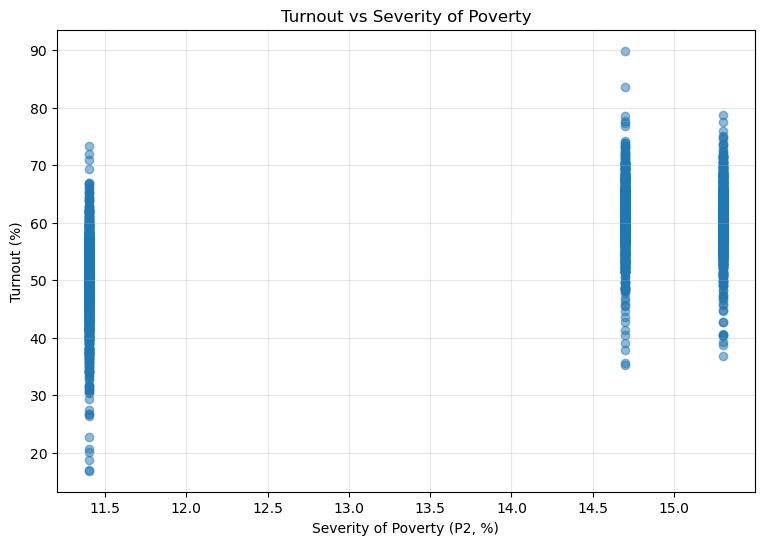

In [25]:
# Plot turnout against the strongest poverty indicator found in our correlation check.
# This helps us see whether the relationship is consistent or driven by a small number of observations.

plt.figure(figsize=(9, 6))

plt.scatter(
    eda_data["Severity of poverty (P2, %)"],
    eda_data["TurnoutRate"],
    alpha=0.5
)

plt.title("Turnout vs Severity of Poverty")
plt.xlabel("Severity of Poverty (P2, %)")
plt.ylabel("Turnout (%)")
plt.grid(True, alpha=0.3)

plt.show()

Poverty context and turnout

The scatter plot shows three distinct vertical groups because the poverty indicators are province-level KZN context variables, rather than separate measurements for each ward. The same poverty-context value is therefore associated with multiple wards within each corresponding context period.

The earlier correlation results should consequently be interpreted as a descriptive association between KZN-wide socioeconomic context and ward-level turnout across election periods, rather than evidence that differences in poverty between individual wards explain differences in turnout.

This distinction is important for our modelling approach. We can retain these variables as contextual features, but we should not treat them as ward-level socioeconomic measurements. We also should not infer causation from these correlations.

In [26]:
# Check how many unique poverty-context values exist for each context year.
# This confirms whether these indicators vary by ward or only across the KZN-wide context periods.

poverty_context_check = (
    eda_data
    .groupby("ProvinceContextYear")[poverty_fields]
    .nunique()
)

print("Unique poverty-context values within each context year:")
print(poverty_context_check)

print("\nNumber of context years:")
print(
    eda_data["ProvinceContextYear"].nunique()
)

Unique poverty-context values within each context year:
                     Food poverty headcount (FPL, %)  \
ProvinceContextYear                                    
2011                                               1   
2015                                               1   
2023                                               1   

                     Gini coefficient (income per capita)  \
ProvinceContextYear                                         
2011                                                    1   
2015                                                    1   
2023                                                    1   

                     Poverty gap (P1, %)  Poverty headcount (P0, %)  \
ProvinceContextYear                                                   
2011                                   1                          1   
2015                                   1                          1   
2023                                   1                          1   

 

Poverty geography validation

We confirmed that each poverty indicator has exactly one value within each ProvinceContextYear. This means the poverty measures represent the KZN-wide socioeconomic context for the three historical periods rather than differences between individual wards.

We therefore retain these variables as contextual information for the modelling pipeline, but we will not interpret them as ward-level poverty measurements. This prevents us from overstating the evidence and keeps the analysis consistent with the geographic level of the source data

In [28]:
# Check how much the demographic context varies across the wards in our dataset.
# We want to confirm which variables provide real geographic variation before comparing them with turnout.

demographic_fields = [
    "Household",
    "Homeless",
    "Transient",
    "Institution",
    "UrbanArea",
    "TribalOrTraditionalArea",
    "FarmArea",
    "MalePopulation",
    "Population"
]

demographic_summary = (
    eda_data[demographic_fields]
    .agg(["count", "nunique", "min", "max"])
    .T
)

print("Demographic context coverage and variation:")
print(demographic_summary)

Demographic context coverage and variation:
                          count  nunique           min           max
Household                2489.0     33.0      0.000000  5.611000e+03
Homeless                 2489.0      7.0      0.000000  1.900000e+01
Transient                2489.0     44.0     45.000000  1.031010e+05
Institution              2489.0     43.0      0.000000  3.534197e+06
UrbanArea                2489.0     44.0     16.424432  6.865080e+05
TribalOrTraditionalArea  2489.0     42.0      0.000000  4.560966e+04
FarmArea                 2489.0     44.0  15763.960764  2.072331e+06
MalePopulation           2489.0     44.0  17618.403497  2.167569e+06
Population               2489.0     44.0  33382.364261  4.239901e+06


Demographic context validation

We found 2,489 records with demographic context, covering the ward-year records where municipality-level context was available. The number of unique values across the variables confirms that these measures vary primarily at the municipality level rather than independently for every ward.

We therefore treat these variables as municipality-level contextual features associated with wards, rather than direct ward-level demographic measurements. This distinction will be maintained when interpreting relationships with turnout.

In [29]:
# Compare turnout with the available demographic context variables.
# We use correlations only as a first descriptive screen before deciding which relationships to visualize.

demographic_correlations = (
    eda_data[
        ["TurnoutRate"] + demographic_fields
    ]
    .corr()["TurnoutRate"]
    .drop("TurnoutRate")
    .sort_values()
)

print("Correlation between turnout and demographic context:")
print(demographic_correlations)

Correlation between turnout and demographic context:
FarmArea                  -0.214183
Population                -0.213965
MalePopulation            -0.213753
Homeless                  -0.213553
UrbanArea                 -0.212764
Institution               -0.212241
Household                 -0.211613
Transient                 -0.209005
TribalOrTraditionalArea   -0.059394
Name: TurnoutRate, dtype: float64



The demographic-context variables show mostly weak negative correlations with ward-level turnout. The strongest are FarmArea (-0.214), Population (-0.214), and MalePopulation (-0.214), while TribalOrTraditionalArea has a much weaker relationship (-0.059).

Because these variables are primarily municipality-level context attached to ward records, we interpret these results as associations between municipal demographic context and ward turnout, not as direct ward-level demographic effects.

The correlations are relatively modest, so demographic context alone does not explain most of the variation in turnout. This supports our decision to combine historical turnout with multiple contextual features in the later predictive modelling stage.


In [36]:
# Check which election years contain the political-attitude context.
# This tells us whether the available attitude data can be compared directly across our historical periods.

attitude_fields = [
    "Dissatisfied with democracy",
    "Distrust of national government",
    "Distrust of political parties",
    "Distrust of provincial government",
    "Distrust of the IEC"
]

attitude_coverage = (
    eda_data
    .groupby("ElectionYear")[attitude_fields]
    .count()
)

print("Political-attitude records available by election year:")
print(attitude_coverage)

print("\nUnique values by election year:")
print(
    eda_data
    .groupby("ElectionYear")[attitude_fields]
    .nunique()
)

Political-attitude records available by election year:
              Dissatisfied with democracy  Distrust of national government  \
ElectionYear                                                                 
2011                                    0                                0   
2016                                    0                                0   
2021                                  901                              901   

              Distrust of political parties  \
ElectionYear                                  
2011                                      0   
2016                                      0   
2021                                    901   

              Distrust of provincial government  Distrust of the IEC  
ElectionYear                                                          
2011                                          0                    0  
2016                                          0                    0  
2021                              

Political-attitude context coverage

The political-attitude indicators are available for 901 records in 2021 only. There are no corresponding records for 2011 or 2016. Within the 2021 records, each indicator has only one unique value, confirming that these are KZN-level contextual measures rather than ward-level differences.

We therefore should not calculate a normal correlation between these variables and turnout across all ward-years. Doing so would mainly reflect the difference between the 2021 context and the earlier years, rather than variation in political attitudes between wards.

We retain these indicators as supporting contextual information, but they should not be interpreted as ward-level predictors in this EDA.


we choose to document this limitation than to try and manufacture missing values we figure that is an important option to make

In [38]:
# Review missing values across the complete feature-engineered dataset before we finish EDA.
# We want to confirm that every remaining gap has an identified structural reason.

missing_summary = (
    eda_data
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_summary = missing_summary[
    missing_summary > 0
]

print("Columns with missing values:")
print(missing_summary)

print("\nTotal columns with missing values:",
      len(missing_summary))

print("\nTotal missing cells:",
      missing_summary.sum())

Columns with missing values:
Distrust of provincial government    1698
Distrust of the IEC                  1698
Distrust of national government      1698
Distrust of political parties        1698
Dissatisfied with democracy          1698
PreviousTurnout                      1165
RegisteredVotersChange               1165
RegistrationGrowth                   1165
Transient                             110
Homeless                              110
TribalOrTraditionalArea               110
FarmArea                              110
Household                             110
BaselinePredictedTurnout2026          110
MalePopulation                        110
Population                            110
Institution                           110
UrbanArea                             110
CurrentMunicipality                   110
dtype: int64

Total columns with missing values: 19

Total missing cells: 13195


Final missingness audit

We identified missing values in 19 of the 53 features, but the missingness follows known structural reasons rather than unexplained data loss.

The 1,698 missing political-attitude values occur because those indicators are available only for the 2021 context period. The 1,165 missing historical-change features occur because PreviousTurnout, RegisteredVotersChange, and RegistrationGrowth cannot be calculated for 2011 and for historical comparisons that were not considered safe under the boundary rules.

The 110 missing municipality-context values occur where municipality context could not be matched, and the corresponding CurrentMunicipality and BaselinePredictedTurnout2026 fields are also missing for those records. These values were not artificially filled during EDA.

Therefore, we have not identified unexplained missingness requiring correction at the EDA stage. The missing values should be handled according to feature availability during modelling rather than removed indiscriminately.

In [39]:
# Trace the 110 records without municipality context so we know exactly where the gaps occur.
# We want to confirm that these rows follow the known municipality-matching limitation before closing EDA.

municipality_context_missing = eda_data[
    eda_data["CurrentMunicipality"].isna()
].copy()

print("Records missing municipality context:",
      len(municipality_context_missing))

print("\nMissing municipality context by election year:")
print(
    municipality_context_missing
    .groupby("ElectionYear")
    .size()
)

print("\nMunicipality codes in missing records:")
print(
    municipality_context_missing["MunicipalityCode"]
    .value_counts(dropna=False)
)

print("\nBoundary consistency in missing records:")
print(
    municipality_context_missing["BoundaryConsistent"]
    .value_counts(dropna=False)
)

Records missing municipality context: 110

Missing municipality context by election year:
ElectionYear
2011    110
dtype: int64

Municipality codes in missing records:
MunicipalityCode
KZN232    27
KZN236    13
KZN431    11
KZN233    10
KZN211    10
KZN234     9
KZN283     8
KZN274     8
KZN215     6
KZN273     4
KZN432     4
Name: count, dtype: int64

Boundary consistency in missing records:
BoundaryConsistent
False    110
Name: count, dtype: int64


Final EDA missing-data conclusion

Our missing-data audit shows that the remaining gaps are explained by known structural characteristics of the datasets. The 110 records without municipality context all occur in 2011 and all have BoundaryConsistent = False. They correspond to historical municipality codes that could not be safely mapped to the current municipality context.

The remaining missing values are similarly attributable to documented feature-availability rules: historical comparison features are unavailable where a previous election cannot be safely established, while political-attitude variables are available only for the 2021 context period.

We therefore found no unexplained missingness requiring correction during EDA. We have preserved the original values rather than artificially imputing or removing records. Any modelling method that requires complete predictors will need to handle feature-specific availability explicitly.

Where we are now

We've completed the core EDA checks:

Turnout validity and distribution

Turnout trends across elections

Individual ward trends

Previous-turnout baseline

Registration-change outlier review

Below-average turnout analysis

Previous-turnout missingness audit

Poverty-context analysis

Demographic-context analysis

Political-attitude coverage

Full missing-data audit